In [2]:
import os
os.chdir(r"C:\Users\HP\Desktop\Academic_Risk_Prediction")

os.getcwd()

'c:\\Users\\HP\\Desktop\\Academic_Risk_Prediction'

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
data = pd.read_csv("balanced_academic_risk_dataset.csv")
print(data.head())

   study_hours_per_day  attendance_percentage  assignment_completion_rate  \
0                  3.7                   79.0                        57.0   
1                  9.5                   76.3                        67.5   
2                  7.3                   67.6                        46.0   
3                  6.0                   74.7                        66.8   
4                  1.6                   68.3                        52.2   

   internal_assessment_score  sleep_hours_per_day  screen_time_hours  \
0                       41.0                  8.4                3.6   
1                       36.7                  5.6                6.1   
2                       39.7                  4.3                7.7   
3                       63.1                  8.6               11.9   
4                       91.9                  6.2                8.3   

   class_participation_level  time_management_score  study_consistency_index  \
0                       

In [5]:
data.columns = data.columns.str.strip()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['academic_risk_level'] = le.fit_transform(data['academic_risk_level'])

print(data.head())

   study_hours_per_day  attendance_percentage  assignment_completion_rate  \
0                  3.7                   79.0                        57.0   
1                  9.5                   76.3                        67.5   
2                  7.3                   67.6                        46.0   
3                  6.0                   74.7                        66.8   
4                  1.6                   68.3                        52.2   

   internal_assessment_score  sleep_hours_per_day  screen_time_hours  \
0                       41.0                  8.4                3.6   
1                       36.7                  5.6                6.1   
2                       39.7                  4.3                7.7   
3                       63.1                  8.6               11.9   
4                       91.9                  6.2                8.3   

   class_participation_level  time_management_score  study_consistency_index  \
0                       

In [8]:
X = data.drop("academic_risk_level", axis=1)
y = data["academic_risk_level"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
import pandas as pd

data = pd.read_csv(r"C:\Users\HP\Desktop\Academic_Risk_Prediction\balanced_academic_risk_dataset.csv")

print(data.head())
print(data.columns)

   study_hours_per_day  attendance_percentage  assignment_completion_rate  \
0                  3.7                   79.0                        57.0   
1                  9.5                   76.3                        67.5   
2                  7.3                   67.6                        46.0   
3                  6.0                   74.7                        66.8   
4                  1.6                   68.3                        52.2   

   internal_assessment_score  sleep_hours_per_day  screen_time_hours  \
0                       41.0                  8.4                3.6   
1                       36.7                  5.6                6.1   
2                       39.7                  4.3                7.7   
3                       63.1                  8.6               11.9   
4                       91.9                  6.2                8.3   

   class_participation_level  time_management_score  study_consistency_index  \
0                       


Model: Logistic Regression
Accuracy: 70.12864020203614

Confusion Matrix:
[[ 8781   833  3057]
 [  118 10497  2056]
 [ 3110  2181  7380]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71     12671
           1       0.78      0.83      0.80     12671
           2       0.59      0.58      0.59     12671

    accuracy                           0.70     38013
   macro avg       0.70      0.70      0.70     38013
weighted avg       0.70      0.70      0.70     38013


Model: Random Forest
Accuracy: 99.97632388919581

Confusion Matrix:
[[12671     0     0]
 [    0 12671     0]
 [    0     9 12662]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12671
           1       1.00      1.00      1.00     12671
           2       1.00      1.00      1.00     12671

    accuracy                           1.00     38013
   macro avg       1.00    

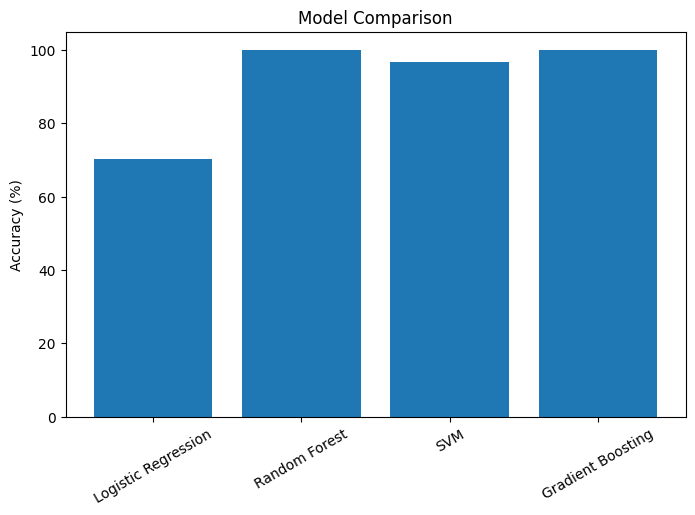

In [13]:


# =========================================
# 1️⃣ Import Libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt


# =========================================
# 2️⃣ Load Dataset
# =========================================
data = pd.read_csv("balanced_academic_risk_dataset.csv")

X = data.drop("academic_risk_level", axis=1)
y = data["academic_risk_level"]


# =========================================
# 3️⃣ Encode Data
# =========================================
le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)


# =========================================
# 4️⃣ Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================
# 5️⃣ Scaling (Important for LR & SVM)
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================================
# 6️⃣ Define Models
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ),

    "SVM": SVC(kernel="rbf"),

    "Gradient Boosting": GradientBoostingClassifier()
}


# =========================================
# 7️⃣ Train & Evaluate Models
# =========================================
results = {}

for name, model in models.items():

    print("\n==============================")
    print("Model:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc

    print("Accuracy:", acc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# =========================================
# 8️⃣ Show Best Model
# =========================================
best_model = max(results, key=results.get)

print("\n🔥 Model Comparison Results:")
for model, score in results.items():
    print(model, ":", score)

print("\n🏆 Best Model:", best_model)
print("Best Accuracy:", results[best_model])


# =========================================
# 9️⃣ Plot Comparison
# =========================================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()

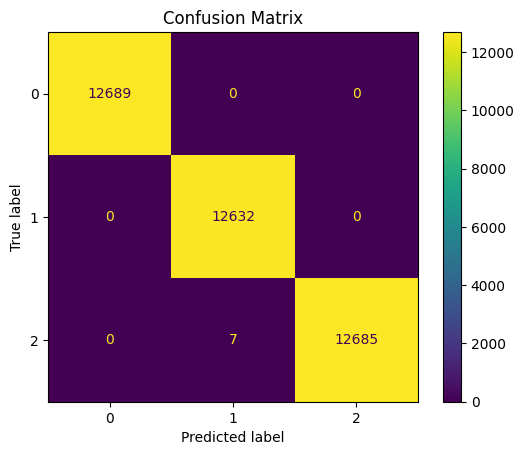

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# 1. Load dataset
df = pd.read_csv("balanced_academic_risk_dataset.csv")

# 2. Remove missing values (safe)
df = df.dropna()

# 3. Define target column
target_col = "academic_risk_level"

# 4. Split features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# 5. Convert labels (High, Medium, Low → numbers)
le = LabelEncoder()
y = le.fit_transform(y)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 8. Predict
y_pred = model.predict(X_test)

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 10. Plot
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)

plt.title("Confusion Matrix")

# 11. Show
plt.show()